# Aplicando Regressao Polinomial

Neste estudo, é aplicado regressao polinomial em uma base de precos de aluguel de imoveis para comparar seu desempenho com a regressao linear simples.

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, r2_score

A classe `PolynomialFeatures` (do modulo `preprocessing` do scikit-learn) transforma as variaveis de entrada em termos polinomiais. Com isso, o modelo passa a considerar nao apenas a variavel original, mas tambem suas potencias, permitindo capturar relacoes nao lineares.

In [3]:
df_imoveis = pd.read_csv("../../Base de Dados/ALUGUEL_MOD12.csv", delimiter=';')

In [4]:
df_imoveis

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
...,...,...,...,...,...,...,...
7198,25000,7500,627,4,5,4,6
7199,25000,4600,364,4,2,1,0
7200,25000,3700,266,3,4,3,7
7201,25000,6000,600,4,5,4,8


In [5]:
y = df_imoveis['Valor_Aluguel']

In [6]:
X = df_imoveis[['Valor_Condominio']]

In [7]:
poly_features = PolynomialFeatures(degree=2)

De forma simples, essa etapa expande a variavel original para incluir termos como `x^2` (ou grau maior, se definido). Assim, em vez de ajustar apenas uma reta, o modelo pode ajustar uma curva e representar melhor padroes mais complexos dos dados.

Com `degree=2`, a transformacao cria termos ate a segunda potencia. Se a entrada for apenas `x`, o modelo passa a trabalhar com `x` e `x^2`, permitindo ajustar curvatura na relacao entre variavel explicativa e alvo.

In [8]:
x_poly = poly_features.fit_transform(X)

Aqui transformamos as variaveis de entrada para um espaco polinomial de grau 2. Depois disso, aplicamos regressao linear sobre essas novas features para modelar uma relacao em curva.

In [9]:
x_poly

array([[1.000000e+00, 2.950000e+02, 8.702500e+04],
       [1.000000e+00, 0.000000e+00, 0.000000e+00],
       [1.000000e+00, 0.000000e+00, 0.000000e+00],
       ...,
       [1.000000e+00, 3.700000e+03, 1.369000e+07],
       [1.000000e+00, 6.000000e+03, 3.600000e+07],
       [1.000000e+00, 1.587000e+03, 2.518569e+06]], shape=(7203, 3))

Com os dados transformados, seguimos o fluxo padrao: separacao treino/teste, treinamento do modelo e avaliacao das previsoes.

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x_poly, y, test_size=0.2, random_state=0)

In [11]:
# Aplicando regressão linear nos dados transformados
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [12]:
print("Tamanho de x_test:", x_test.shape)
print("Tamanho de y_test:", y_test.shape)

Tamanho de x_test: (1441, 3)
Tamanho de y_test: (1441,)


/home/ramon/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


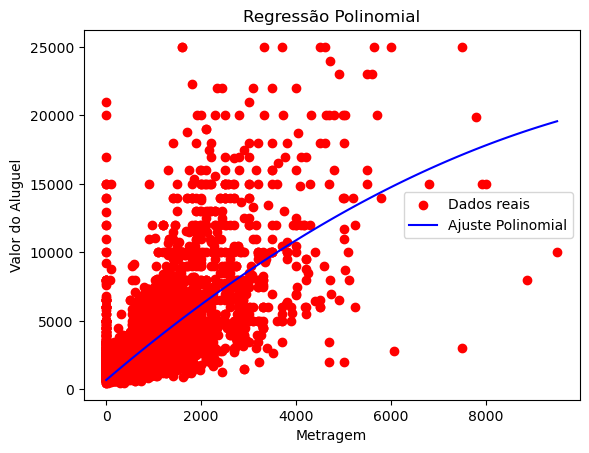

In [13]:
y_pred = model.predict(x_test)

# CriarEmos uma sequência de valores X para a visualização, buscando a suavização
x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
x_range_poly = poly_features.transform(x_range)
y_range_pred = model.predict(x_range_poly)

plt.scatter(X, y, color='red', label='Dados reais')  # Dados reais
plt.plot(x_range, y_range_pred, color='blue', label='Ajuste Polinomial')  # Linha do ajuste
plt.xlabel('Metragem')
plt.ylabel('Valor do Aluguel')
plt.title('Regressão Polinomial')
plt.legend()
plt.show()

Agora uma regressao linear simples para comparar diretamente com o modelo polinomial.

In [14]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [15]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [16]:
y_pred_linear = model.predict(x_test)

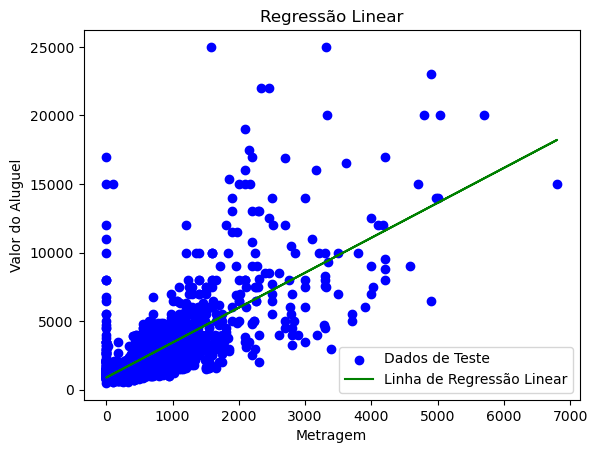

In [17]:
plt.scatter(x_test, y_test, color='blue', label='Dados de Teste')  # Dados de teste
plt.plot(x_test, y_pred_linear, color='green', label='Linha de Regressão Linear')  # Linha de regressão
plt.xlabel('Metragem')
plt.ylabel('Valor do Aluguel')
plt.title('Regressão Linear')
plt.legend()
plt.show()

In [18]:
r2_linear = r2_score(y_test, y_pred_linear)
print(f'R² da Regressão Linear: {r2_linear:.4f}')

R² da Regressão Linear: 0.4963


In [19]:
r2 = r2_score(y_test, y_pred)
print(f'R² da Regressão Polinomial: {r2:.4f}')

R² da Regressão Polinomial: 0.4921


Os dois modelos apresentaram valores de R2 parecidos. Isso sugere que, para esta base especifica, a transformacao polinomial de grau 2 nao trouxe ganho substancial em relacao ao modelo linear simples.

## **Aplicando Regressao Ridge, Lasso e Elastic Net**

In [20]:
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

Antes de aplicar regularizacao (Ridge, Lasso e Elastic Net), e importante analisar a relacao entre as variaveis. Um passo essencial e observar a matriz de correlacao para detectar possivel multicolinearidade.

In [21]:
df_imoveis.corr(method='pearson')

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
Valor_Aluguel,1.000000,0.695302,0.730591,0.413139,0.603715,0.614397,0.652858
Valor_Condominio,0.695302,1.000000,0.805926,0.497420,0.585795,0.589244,0.690993
Metragem,0.730591,0.805926,1.000000,0.678091,0.687558,0.696281,0.743872
N_Quartos,0.413139,0.497420,0.678091,1.000000,0.553807,0.540887,0.591224
N_banheiros,0.603715,0.585795,0.687558,0.553807,1.000000,0.920149,0.694983
N_Suites,0.614397,0.589244,0.696281,0.540887,0.920149,1.000000,0.712054
N_Vagas,0.652858,0.690993,0.743872,0.591224,0.694983,0.712054,1.000000


Se duas ou mais variaveis explicativas estiverem altamente correlacionadas (proximas de 1 ou -1), ha indicio de multicolinearidade. Isso pode gerar coeficientes instaveis e dificultar a interpretacao do modelo.

A alta correlacao entre `N_suites` e `N_banheiros` e um exemplo de multicolinearidade, situacao em que tecnicas de regularizacao podem ajudar a estabilizar o modelo.

A correlacao alta entre variaveis pode ter efeitos diferentes, dependendo do contexto:

**1) Entre variaveis independentes (features):**
- Pode causar multicolinearidade.
- Pode gerar coeficientes instaveis.
- Pode trazer redundancia de informacao.
- Pode dificultar a interpretacao individual de cada feature.

**2) Entre feature e target:**
- Em geral, e desejavel, pois indica poder explicativo para previsao.

Quando ha alta correlacao entre variaveis explicativas e a target, isso tende a ser positivo para capacidade preditiva do modelo.

## Modelo de Regressao Ridge

In [31]:
# Criando e treinando o modelo Ridge:
ridge_model = Ridge(alpha=0.1)  # Alpha é o parâmetro de regularização, testar: 1.0/ 100 /0.01
ridge_model.fit(x_train, y_train)

y_pred_ridge = ridge_model.predict(x_test)

# Avaliando o modelo
print("Ridge Regressão")
print("R^2 Score:", r2_score(y_test, y_pred_ridge))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_ridge))

Ridge Regressão
R^2 Score: 0.49629320151320855
Mean Squared Error: 4668978.552905872


`alpha` controla a intensidade da penalizacao da regularizacao.

- **Alpha baixo:** menor penalizacao, modelo mais flexivel e maior risco de overfitting.
- **Alpha alto:** maior penalizacao, modelo mais simples e, em geral, melhor generalizacao em dados nao vistos.

## Modelo Lasos

In [32]:
# Criando e treinando o modelo Lasso
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(x_train, y_train)

y_pred_lasso = lasso_model.predict(x_test)

# Avaliando o modelo
print("Lasso Regressão")
print("R^2 Score:", r2_score(y_test, y_pred_lasso))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_lasso))

Lasso Regressão
R^2 Score: 0.4962931739207457
Mean Squared Error: 4668978.808666997


## Modelo Elastic

In [33]:
# Criando e treinando o modelo Elastic Net
elastic_net_model = ElasticNet(alpha=1.0, l1_ratio=0.5)  # Alpha e l1_ratio são parâmetros de regularização
elastic_net_model.fit(x_train, y_train)

# Fazendo previsões
y_pred_elastic_net = elastic_net_model.predict(x_test)

# Avaliando o modelo
print("Elastic Net Regressão")
print("R^2 Score:", r2_score(y_test, y_pred_elastic_net))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_elastic_net))

Elastic Net Regressão
R^2 Score: 0.49629315255716755
Mean Squared Error: 4668979.006691102


**R2 Score** mede a proporcao da variancia da variavel alvo explicada pelo modelo (quanto maior, melhor ajuste).

**MSE** mede a media dos erros ao quadrado entre valores reais e previstos (quanto menor, melhor).

Se o modelo base ja for simples e nao estiver em overfitting, a regularizacao pode nao trazer melhoria significativa nas metricas.